In [16]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import string
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import utils_funs

dataset = load_dataset("imdb")

train_df = pd.DataFrame({
    'review': dataset['train']['text'],
    'label':  dataset['train']['label']
})

test_df = pd.DataFrame({
    'review': dataset['test']['text'],
    'label':  dataset['test']['label']
})

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
train_df.head()

Train size: 25000
Test size:  25000


,review,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [17]:
def preprocess_text(text):
    text = text.lower()
    text = text.replace("<br />", " ")
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    return tokens

train_df['tokens'] = train_df['review'].apply(preprocess_text)
test_df['tokens']  = test_df['review'].apply(preprocess_text)

train_df.head()

,review,label,tokens
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,"[i, rented, i, am, curiousyellow, from, my, vi..."
1,"""I Am Curious: Yellow"" is a risible and preten...",0,"[i, am, curious, yellow, is, a, risible, and, ..."
2,If only to avoid making this type of film in t...,0,"[if, only, to, avoid, making, this, type, of, ..."
3,This film was probably inspired by Godard's Ma...,0,"[this, film, was, probably, inspired, by, goda..."
4,"Oh, brother...after hearing about this ridicul...",0,"[oh, brotherafter, hearing, about, this, ridic..."


In [18]:
def build_vocabulary(tokens_series):
    vocab = {}
    index = 0
    for tokens in tokens_series:
        for word in tokens:
            if word not in vocab:
                vocab[word] = index
                index += 1
    return vocab

vocab = build_vocabulary(train_df['tokens'])
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 112011


In [19]:
def build_bow_matrix(tokens_series, vocab):
    tokens_list = list(tokens_series)
    matrix = np.zeros((len(tokens_list), len(vocab)), dtype=np.int16)
    for i, tokens in enumerate(tokens_list):
        for word in tokens:
            if word in vocab:
                matrix[i][vocab[word]] += 1
    return matrix

train_bow = build_bow_matrix(train_df['tokens'], vocab)
test_bow  = build_bow_matrix(test_df['tokens'],  vocab)

In [20]:
def compute_prior(df):
    total     = len(df)
    priors = {}
    priors[1] = len(df[df['label'] == 1]) / total
    priors[0] = len(df[df['label'] == 0]) / total
    return priors

priors = compute_prior(train_df)
print(f"P(positive) = {priors[1]}")
print(f"P(negative) = {priors[0]}")

P(positive) = 0.5
P(negative) = 0.5


# Word Probabilities with Laplace Smoothing

In [21]:
def compute_word_prob(labels, vocab, train_bow):
    word_prob = {}

    for cls in set(labels):
        cls_indices = []
        for i in range(len(labels)):
            if labels[i] == cls:
                cls_indices.append(i)

        cls_bow = train_bow[cls_indices]
        word_count = cls_bow.sum(axis=0)
        total_words = word_count.sum()
        word_prob[cls] = (word_count + 1) / (total_words + len(vocab))

    return word_prob

word_prob = compute_word_prob(train_df['label'].tolist(), vocab, train_bow)

In [22]:
def predict(bow_matrix, word_prob, priors, with_log):
    predictions = []

    for row in bow_matrix:
        cls_scores = {}
        for cls in priors:
            if with_log:
                score = (np.log(priors[cls])
                         + np.sum(np.log(word_prob[cls]) * row))
            else:
                score = (priors[cls]
                         * np.prod(word_prob[cls] ** row))

            cls_scores[cls] = score

        predictions.append(max(cls_scores, key=cls_scores.get))

    return predictions

# with log
y_pred_log = predict(test_bow, word_prob, priors, with_log=True)
acc_log = utils_funs.compute_accuracy(test_df['label'].tolist(), y_pred_log)

# without log
y_pred = predict(test_bow, word_prob, priors, with_log=False)
acc = utils_funs.compute_accuracy(test_df['label'].tolist(), y_pred)

results = pd.DataFrame({
    'Method': ['With Log Probabilities', 'Without Log Probabilities'],
    'Accuracy': [acc_log, acc]
})

print(results)

                      Method  Accuracy
0     With Log Probabilities    81.572
1  Without Log Probabilities    54.728


# Top 20 Most Frequent Words

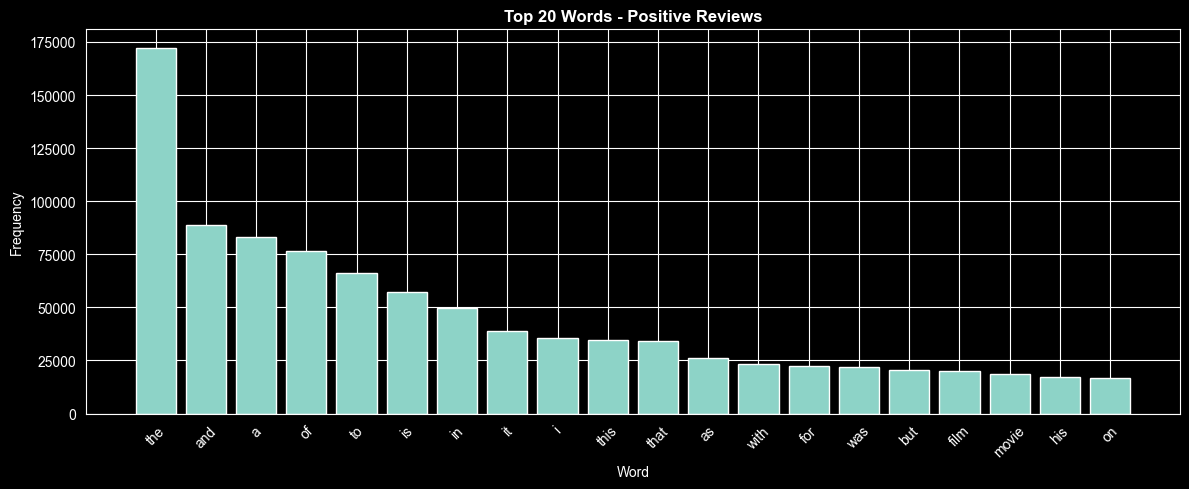

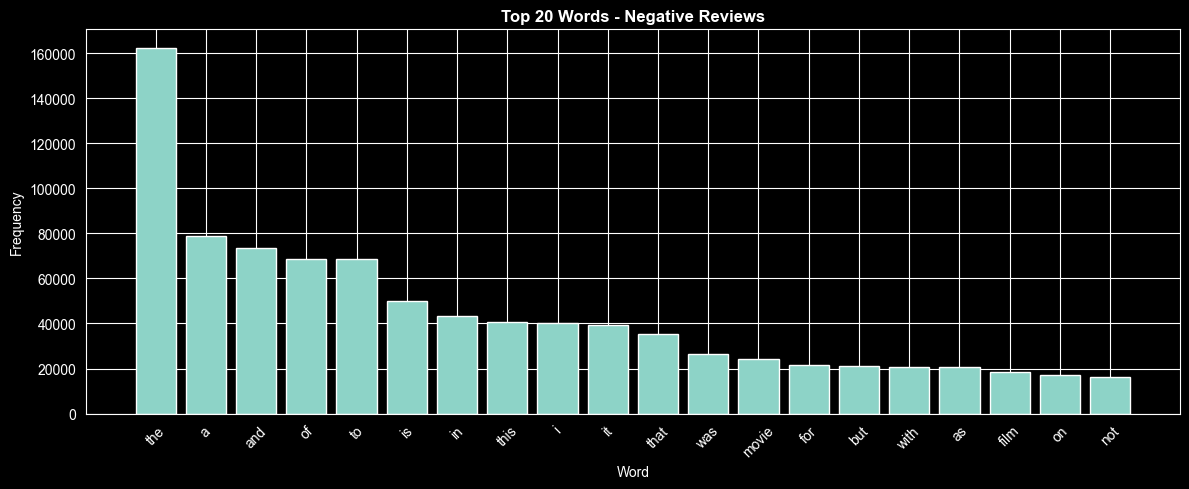

In [23]:
from collections import defaultdict

pos_counts = defaultdict(int)
neg_counts = defaultdict(int)

for i in range(len(train_df)):
    words = train_df['tokens'][i]
    label = train_df['label'][i]

    if label == 1:
        for word in words:
            pos_counts[word] += 1
    else:
        for word in words:
            neg_counts[word] += 1

# get top 20 for each
top_pos = sorted(pos_counts.items(), key=lambda x: x[1], reverse=True)[:20]
top_neg = sorted(neg_counts.items(), key=lambda x: x[1], reverse=True)[:20]

# separate words & counts
pos_words = []
pos_counts_vals = []
for word, count in top_pos:
    pos_words.append(word)
    pos_counts_vals.append(count)

neg_words = []
neg_counts_vals = []
for word, count in top_neg:
    neg_words.append(word)
    neg_counts_vals.append(count)

# plot pos
plt.figure(figsize=(12, 5))
plt.bar(pos_words, pos_counts_vals)
plt.title('Top 20 Words - Positive Reviews', fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot neg
plt.figure(figsize=(12, 5))
plt.bar(neg_words, neg_counts_vals)
plt.title('Top 20 Words - Negative Reviews', fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()